# Imports

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import time

# Download ECG5000

In [ ]:
# ECG5000 is available directly from UCR archive
!wget -q "https://www.timeseriesclassification.com/aeon-toolkit/ECG5000.zip"
!unzip -q ECG5000.zip

# Load
train = pd.read_csv("ECG5000_TRAIN.txt", header=None, sep=r'\s+')
test  = pd.read_csv("ECG5000_TEST.txt",  header=None, sep=r'\s+')

# First column is label, rest is signal
X_train = train.iloc[:, 1:].values.astype(np.float32)
y_train = train.iloc[:, 0].values
X_test  = test.iloc[:, 1:].values.astype(np.float32)
y_test  = test.iloc[:, 0].values

# Encode labels to 0-indexed
le = LabelEncoder()
y_train = le.fit_transform(y_train).astype(np.int64)
y_test  = le.transform(y_test).astype(np.int64)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Sequence length: {X_train.shape[1]}")
print(f"Classes: {len(np.unique(y_train))}")

Train: (500, 140), Test: (4500, 140)
Sequence length: 140
Classes: 5


# Normalize and build DataLoaders

In [ ]:
# Normalize per sample (zero mean, unit variance)
mean = X_train.mean(axis=1, keepdims=True)
std  = X_train.std(axis=1, keepdims=True) + 1e-8
X_train = (X_train - mean) / std

mean = X_test.mean(axis=1, keepdims=True)
std  = X_test.std(axis=1, keepdims=True) + 1e-8
X_test = (X_test - mean) / std

# Add channel dimension → (batch, 1, T)
X_train = torch.tensor(X_train).unsqueeze(1)
X_test  = torch.tensor(X_test).unsqueeze(1)
y_train = torch.tensor(y_train)
y_test  = torch.tensor(y_test)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test, y_test),  batch_size=32, shuffle=False)

print(f"Input shape: {X_train.shape}")

Input shape: torch.Size([500, 1, 140])


In [ ]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(123)

# CNN + temporal pooling

In [ ]:
class CNN_TemporalPooling(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.network(x)
        x = self.gap(x).squeeze(-1)
        return self.classifier(x)

# CNN + LSTM

In [ ]:
class CNN_LSTM(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.ReLU(),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.lstm = nn.LSTM(input_size=128, hidden_size=128,
                            num_layers=2, batch_first=True)
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.cnn(x)           # (batch, 128, T)
        x = x.permute(0, 2, 1)   # (batch, T, 128)
        _, (h_n, _) = self.lstm(x)
        x = h_n[-1]               # last layer hidden state
        return self.classifier(x)

# Training

In [ ]:
def train_model(model, train_loader, test_loader, epochs=50, lr=1e-3, filename="", patience=10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses, test_accuracies = [], []
    start = time.time()
    best_acc = 0
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        # Evaluate
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(device)
                preds = model(X_batch).argmax(dim=1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(y_batch.numpy())

        acc = accuracy_score(all_labels, all_preds)
        train_losses.append(epoch_loss / len(train_loader))
        test_accuracies.append(acc)

        if acc > best_acc:
          best_acc = acc
          patience_counter = 0
          if filename:
            torch.save(model.state_dict(), f'best_{filename}.pt')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}, best val_acc={best_acc:.4f}")
                break


        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Loss: {train_losses[-1]:.4f} | Acc: {acc:.4f}")

    training_time = time.time() - start
    return train_losses, test_accuracies, training_time, best_acc

# Run, Plot and record results

In [ ]:
NUM_CLASSES = len(np.unique(y_train.numpy()))

print("Training CNN + Temporal Pooling...")
set_seed(123)
cnn_pool = CNN_TemporalPooling(NUM_CLASSES)
pool_losses, pool_accs, pool_time, pool_best = train_model(cnn_pool, train_loader, test_loader)

print("\nTraining CNN + LSTM...")
set_seed(123)
cnn_lstm = CNN_LSTM(NUM_CLASSES)
lstm_losses, lstm_accs, lstm_time, lstm_best = train_model(cnn_lstm, train_loader, test_loader)

print(f"Best accuracy | LSTM: {lstm_best} | Pooling: {pool_best}")

Training CNN + Temporal Pooling...
Epoch 10/50 | Loss: 0.3456 | Acc: 0.9127
Epoch 20/50 | Loss: 0.2575 | Acc: 0.9256
Epoch 30/50 | Loss: 0.2374 | Acc: 0.9284
Epoch 40/50 | Loss: 0.2167 | Acc: 0.9298
Epoch 50/50 | Loss: 0.1974 | Acc: 0.9304

Training CNN + LSTM...
Epoch 10/50 | Loss: 0.2977 | Acc: 0.9091
Epoch 20/50 | Loss: 0.3233 | Acc: 0.9089
Early stopping at epoch 28, best val_acc=0.9278
Best accuracy | LSTM: 0.9277777777777778 | Pooling: 0.9304444444444444


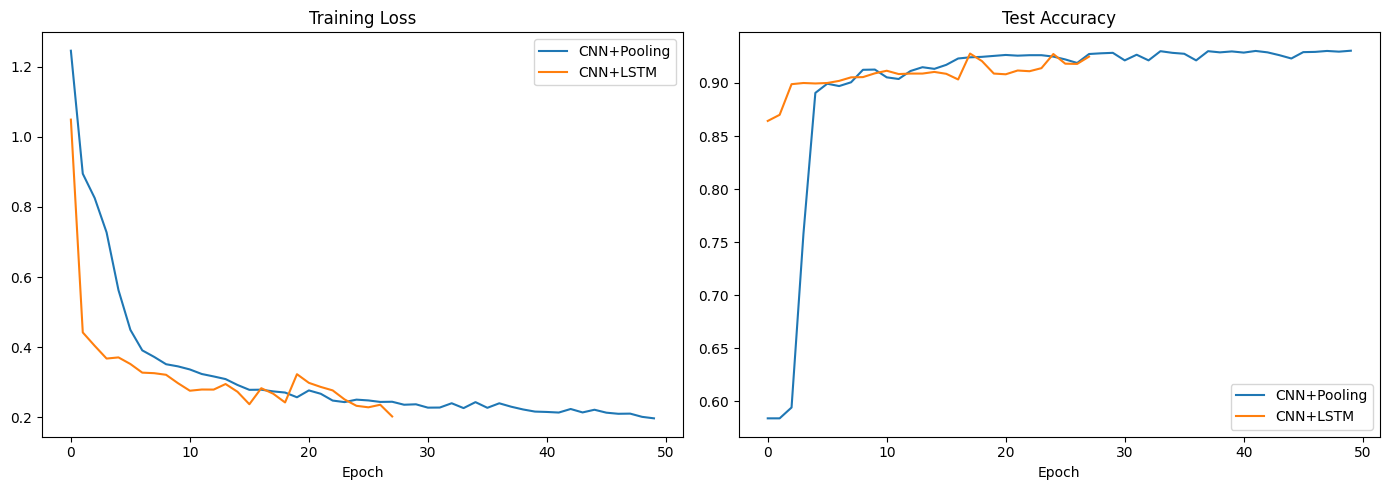


--- Final Results on ECG5000 ---
CNN+Pooling  | Acc: 0.9304 | Time: 11.0s | Params: 35909
CNN+LSTM     | Acc: 0.9278 | Time: 11.3s | Params: 300101


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(pool_losses, label='CNN+Pooling')
axes[0].plot(lstm_losses, label='CNN+LSTM')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(pool_accs, label='CNN+Pooling')
axes[1].plot(lstm_accs, label='CNN+LSTM')
axes[1].set_title('Test Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n--- Final Results on ECG5000 ---")
print(f"CNN+Pooling  | Acc: {max(pool_accs):.4f} | Time: {pool_time:.1f}s | Params: {sum(p.numel() for p in cnn_pool.parameters())}")
print(f"CNN+LSTM     | Acc: {max(lstm_accs):.4f} | Time: {lstm_time:.1f}s | Params: {sum(p.numel() for p in cnn_lstm.parameters())}")

# Performance vs Sequence Length


Training with sequence length 20...
Epoch 10/50 | Loss: 0.2581 | Acc: 0.9242
Epoch 20/50 | Loss: 0.1882 | Acc: 0.9238
Epoch 30/50 | Loss: 0.1741 | Acc: 0.9253
Epoch 40/50 | Loss: 0.1521 | Acc: 0.9280
Early stopping at epoch 46, best val_acc=0.9287
Epoch 10/50 | Loss: 0.3420 | Acc: 0.9131
Epoch 20/50 | Loss: 0.2180 | Acc: 0.9220
Epoch 30/50 | Loss: 0.1703 | Acc: 0.9284
Early stopping at epoch 40, best val_acc=0.9284
Length 20 | CNN+Pooling: 0.9287 | CNN+LSTM: 0.9284

Training with sequence length 30...
Epoch 10/50 | Loss: 0.2553 | Acc: 0.9240
Early stopping at epoch 19, best val_acc=0.9249
Epoch 10/50 | Loss: 0.3545 | Acc: 0.8687
Epoch 20/50 | Loss: 0.1959 | Acc: 0.9184
Epoch 30/50 | Loss: 0.1922 | Acc: 0.9182
Epoch 40/50 | Loss: 0.1660 | Acc: 0.9202
Early stopping at epoch 49, best val_acc=0.9229
Length 30 | CNN+Pooling: 0.9249 | CNN+LSTM: 0.9229

Training with sequence length 40...
Epoch 10/50 | Loss: 0.2726 | Acc: 0.9247
Epoch 20/50 | Loss: 0.2074 | Acc: 0.9233
Early stopping at epo

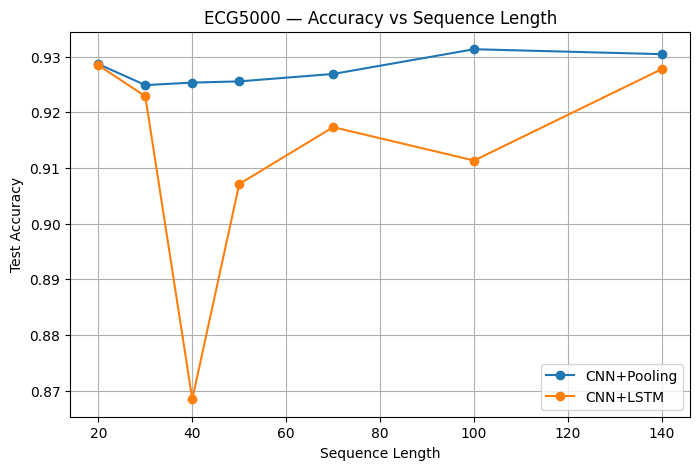

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lengths = [20, 30, 40, 50, 70, 100, 140]
pool_length_accs = []
lstm_length_accs = []

for length in lengths:
    print(f"\nTraining with sequence length {length}...")

    # Truncate
    X_train_short = X_train[:, :, :length]
    X_test_short  = X_test[:, :, :length]

    train_loader_s = DataLoader(TensorDataset(X_train_short, y_train), batch_size=32, shuffle=True)
    test_loader_s  = DataLoader(TensorDataset(X_test_short, y_test),   batch_size=32, shuffle=False)

    # CNN+Pooling
    set_seed(123)
    model_pool = CNN_TemporalPooling(NUM_CLASSES).to(device)
    filename = ""
    if length == 40 or length == 140:
        filename=f"pool_{length}"
    _, accs_pool, _, _ = train_model(model_pool, train_loader_s, test_loader_s, epochs=50, filename=filename)
    pool_length_accs.append(max(accs_pool))

    # CNN+LSTM
    set_seed(123)
    model_lstm = CNN_LSTM(NUM_CLASSES).to(device)
    filename = ""
    if length == 40 or length == 140:
        filename=f"lstm_{length}"
    _, accs_lstm, _, _ = train_model(model_lstm, train_loader_s, test_loader_s, epochs=50, filename=filename)
    lstm_length_accs.append(max(accs_lstm))

    print(f"Length {length} | CNN+Pooling: {pool_length_accs[-1]:.4f} | CNN+LSTM: {lstm_length_accs[-1]:.4f}")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(lengths, pool_length_accs, marker='o', label='CNN+Pooling')
plt.plot(lengths, lstm_length_accs, marker='o', label='CNN+LSTM')
plt.xlabel('Sequence Length')
plt.ylabel('Test Accuracy')
plt.title('ECG5000 — Accuracy vs Sequence Length')
plt.legend()
plt.grid(True)
plt.show()

# Performance vs Noise Level

Sigma 0.0 | CNN+Pooling: 0.9304 | CNN+LSTM: 0.9249
Sigma 0.1 | CNN+Pooling: 0.9302 | CNN+LSTM: 0.9267
Sigma 0.3 | CNN+Pooling: 0.9251 | CNN+LSTM: 0.9251
Sigma 0.5 | CNN+Pooling: 0.8780 | CNN+LSTM: 0.9238
Sigma 1.0 | CNN+Pooling: 0.5847 | CNN+LSTM: 0.9136


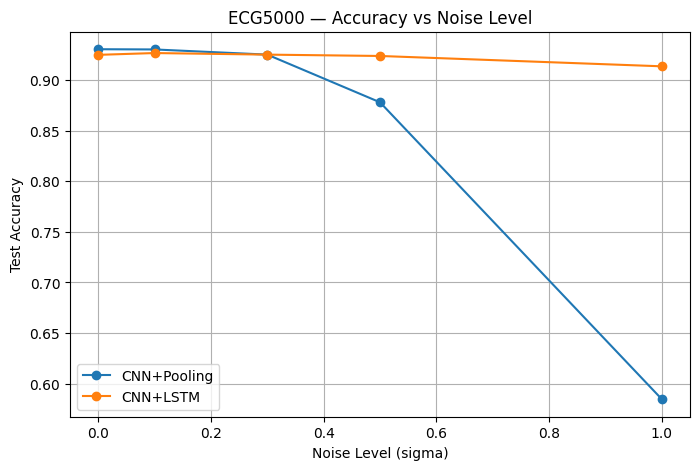

In [ ]:
# Use the already trained models from Cell 7 — no retraining needed
# We are testing robustness of learned representations to noise

sigmas = [0.0, 0.1, 0.3, 0.5, 1.0]
pool_noise_accs = []
lstm_noise_accs = []

cnn_pool.eval()
cnn_lstm.eval()

for sigma in sigmas:
    pool_preds, lstm_preds, all_labels = [], [], []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_noisy = X_batch.to(device) + sigma * torch.randn_like(X_batch).to(device)

            pool_pred = cnn_pool.to(device)(X_noisy).argmax(dim=1).cpu().numpy()
            lstm_pred = cnn_lstm.to(device)(X_noisy).argmax(dim=1).cpu().numpy()

            pool_preds.extend(pool_pred)
            lstm_preds.extend(lstm_pred)
            all_labels.extend(y_batch.numpy())

    pool_noise_accs.append(accuracy_score(all_labels, pool_preds))
    lstm_noise_accs.append(accuracy_score(all_labels, lstm_preds))
    print(f"Sigma {sigma:.1f} | CNN+Pooling: {pool_noise_accs[-1]:.4f} | CNN+LSTM: {lstm_noise_accs[-1]:.4f}")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(sigmas, pool_noise_accs, marker='o', label='CNN+Pooling')
plt.plot(sigmas, lstm_noise_accs, marker='o', label='CNN+LSTM')
plt.xlabel('Noise Level (sigma)')
plt.ylabel('Test Accuracy')
plt.title('ECG5000 — Accuracy vs Noise Level')
plt.legend()
plt.grid(True)
plt.show()

# Summary table of all results

In [ ]:
print("="*60)
print("FULL RESULTS SUMMARY — ECG5000")
print("="*60)

print("\n1. Baseline")
print(f"   CNN+Pooling : {max(pool_accs):.4f} | {pool_time:.1f}s | {sum(p.numel() for p in cnn_pool.parameters())} params")
print(f"   CNN+LSTM    : {max(lstm_accs):.4f} | {lstm_time:.1f}s | {sum(p.numel() for p in cnn_lstm.parameters())} params")

print("\n2. Accuracy vs Sequence Length")
print(f"   {'Length':<10} {'CNN+Pooling':<15} {'CNN+LSTM'}")
for l, p, q in zip(lengths, pool_length_accs, lstm_length_accs):
    print(f"   {l:<10} {p:<15.4f} {q:.4f}")

print("\n3. Accuracy vs Noise Level")
print(f"   {'Sigma':<10} {'CNN+Pooling':<15} {'CNN+LSTM'}")
for s, p, q in zip(sigmas, pool_noise_accs, lstm_noise_accs):
    print(f"   {s:<10} {p:<15.4f} {q:.4f}")

FULL RESULTS SUMMARY — ECG5000

1. Baseline
   CNN+Pooling : 0.9304 | 11.0s | 35909 params
   CNN+LSTM    : 0.9278 | 11.3s | 300101 params

2. Accuracy vs Sequence Length
   Length     CNN+Pooling     CNN+LSTM
   20         0.9287          0.9284
   30         0.9249          0.9229
   40         0.9253          0.8684
   50         0.9256          0.9071
   70         0.9269          0.9173
   100        0.9313          0.9113
   140        0.9304          0.9278

3. Accuracy vs Noise Level
   Sigma      CNN+Pooling     CNN+LSTM
   0.0        0.9304          0.9249
   0.1        0.9302          0.9267
   0.3        0.9251          0.9251
   0.5        0.8780          0.9238
   1.0        0.5847          0.9136
